# Plot Figure 3A & S12 - Calibration

This notebook generates the main data figure comparing fluorescent intensities of HQNO and RHL reporters at defined at concentrations between flow-cytometry and microfluidics 

Code for the additional figure panels, containing model fitting, are provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel)  

In [ ]:
# Data analysis packages
import numpy as np
import pandas as pd
import seaborn as sns
import re

# Visualization packages
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Matplotlib style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


# Strain colors
COLORS_H = {
    'wt': '#ffcc66',       
    '∆pqsL': '#669966',    
    '∆pqsL ∆rhlA': '#9999B3' 
}

COLORS_R = {
    'wt': '#ffcc66',       
    '∆rhlA': '#cc99ff',    
    '∆rhlA ∆pqsL': '#9999B3' 
}


# =============================================================================
# LOAD DATA
# =============================================================================

# Load regrowth fraction data from all strains (relative paths)
df_hqno_microscopy_raw = pd.read_csv('../analysis_code/hqno_calibration_microscopy.csv')
df_rhl_microscopy_raw = pd.read_csv('../analysis_code/rhl_calibration_microscopy.csv')


df_hqno_facs = pd.read_csv('hqno_calibration_facs.csv')
df_rhl_facs = pd.read_csv('rhl_calibration_facs.csv')


# =============================================================================
# PREPROCESSING
# =============================================================================

def parse_concentration(series):
    """Parse numeric concentration from HQNO/RHL column strings.
    
    Handles formats like:
      HQNO-10ng, HQNO_160, RHL-12-5µg, RHL_0_78125
    Steps: strip prefix (HQNO_/HQNO-/RHL_/RHL-), strip unit (ng/µg),
           replace remaining _ or - with . for decimal point.
    """
    def _parse(s):
        s = re.sub(r'^(HQNO|RHL)[_-]', '', s)  # remove prefix
        s = re.sub(r'(ng|µg)$', '', s)           # remove unit
        s = s.replace('_', '.').replace('-', '.') # decimal separator
        return float(s)
    return series.apply(_parse)

#take median per chamber for microscopy data, to match the single value per chamber in FACS data
df_hqno_microscopy = df_hqno_microscopy_raw.groupby(['HQNO', 'replicate', 'pos']).median(numeric_only=True).reset_index()
df_rhl_microscopy = df_rhl_microscopy_raw.groupby(['RHL', 'replicate', 'pos']).median(numeric_only=True).reset_index()

# Standardize columns across datasets for merging and plotting
df_hqno_microscopy['concentration'] = parse_concentration(df_hqno_microscopy['HQNO'])
df_hqno_microscopy['molecule'] = 'HQNO'
df_hqno_microscopy['method'] = 'microfluidics'
df_hqno_microscopy['intensity'] = df_hqno_microscopy['intensity_raw_gfp']  

df_rhl_microscopy['concentration'] = parse_concentration(df_rhl_microscopy['RHL'])
df_rhl_microscopy['molecule'] = 'RHL'
df_rhl_microscopy['method'] = 'microfluidics'
df_rhl_microscopy['intensity'] = df_rhl_microscopy['intensity_raw_mcherry']  

df_hqno_facs['concentration'] = parse_concentration(df_hqno_facs['HQNO'])
df_hqno_facs['molecule'] = 'HQNO'
df_hqno_facs['method'] = 'facs'
df_hqno_facs['intensity'] = df_hqno_facs['median_gfp']  

df_rhl_facs['concentration'] = parse_concentration(df_rhl_facs['RHL'])
df_rhl_facs['molecule'] = 'RHL'
df_rhl_facs['method'] = 'facs'
df_rhl_facs['intensity'] = df_rhl_facs['median_mcherry']  

#merge all datasets into one for easier plotting
KEEP_COLS = ['concentration', 'molecule', 'method', 'intensity']

df_combined = pd.concat(
    [df_hqno_microscopy[KEEP_COLS], df_rhl_microscopy[KEEP_COLS],
     df_hqno_facs[KEEP_COLS], df_rhl_facs[KEEP_COLS]],
    ignore_index=True
)

## Plot Dose response curves

Note that at high HQNO concentrations the toxic affects start to dominate reducing reporter intensities. 

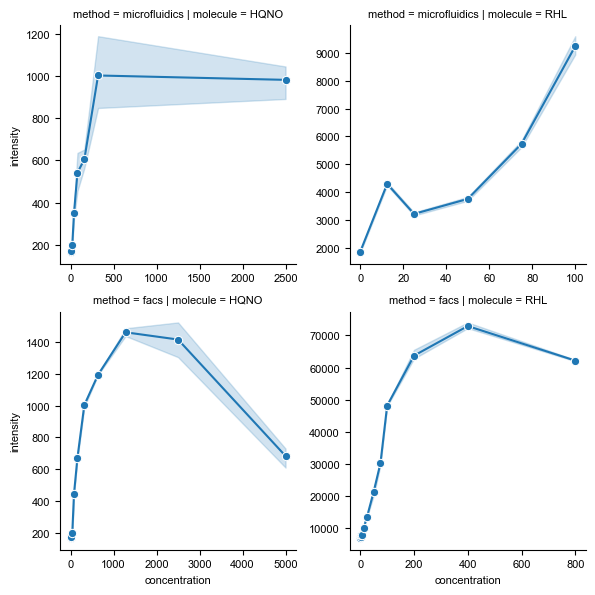

In [15]:
g = sns.FacetGrid(df_combined, col='molecule', row='method', sharex=False, sharey=False)
g.map_dataframe(sns.lineplot, x='concentration', y='intensity', marker='o')


## Plot calibration data

Note that at low concentration of HQNO reporter is below LOD of FACS, but not microscope. The full fitting of calibration curves is done in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel)  


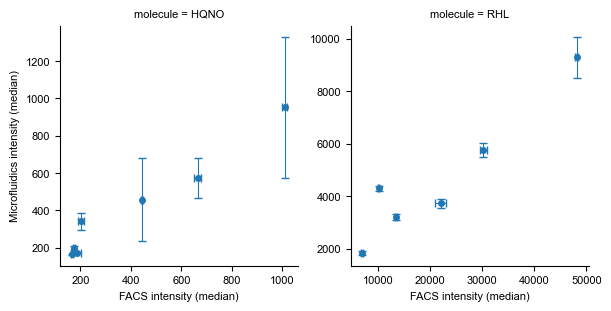

In [16]:
# Exclude HQNO concentrations above 2000
df_filtered = df_combined[
    ~((df_combined['molecule'] == 'HQNO') & (df_combined['concentration'] > 2000))
].copy()

# Aggregate median and std per molecule / concentration / method
df_agg = (
    df_filtered
    .groupby(['molecule', 'concentration', 'method'])['intensity']
    .agg(median='median', std='std')
    .reset_index()
)

# Pivot so facs and microfluidics become separate columns
df_pivot = df_agg.pivot_table(
    index=['molecule', 'concentration'],
    columns='method',
    values=['median', 'std']
).reset_index()

# Flatten MultiIndex columns  →  median_facs, median_microfluidics, std_facs, std_microfluidics
df_pivot.columns = ['_'.join(col).strip('_') for col in df_pivot.columns]

# Scatter: FACS (x) vs microfluidics (y), error bars in both directions
def plot_facs_vs_micro(data, **kwargs):
    ax = plt.gca()
    ax.errorbar(
        data['median_facs'], data['median_microfluidics'],
        xerr=data['std_facs'], yerr=data['std_microfluidics'],
        fmt='o', capsize=3, linewidth=0.8, markersize=4
    )

g = sns.FacetGrid(df_pivot, col='molecule', sharex=False, sharey=False)
g.map_dataframe(plot_facs_vs_micro)
g.set_axis_labels('FACS intensity (median)', 'Microfluidics intensity (median)')